In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import sklearn
import os
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'
import plotly.graph_objects as go
import pandas as pd

[0.1030909090909091, 0.2210909090909091, 0.3201818181818182, 0.24963636363636363, 0.6298181818181818, 0.7094545454545454, 0.6641818181818182, 0.6858181818181818]


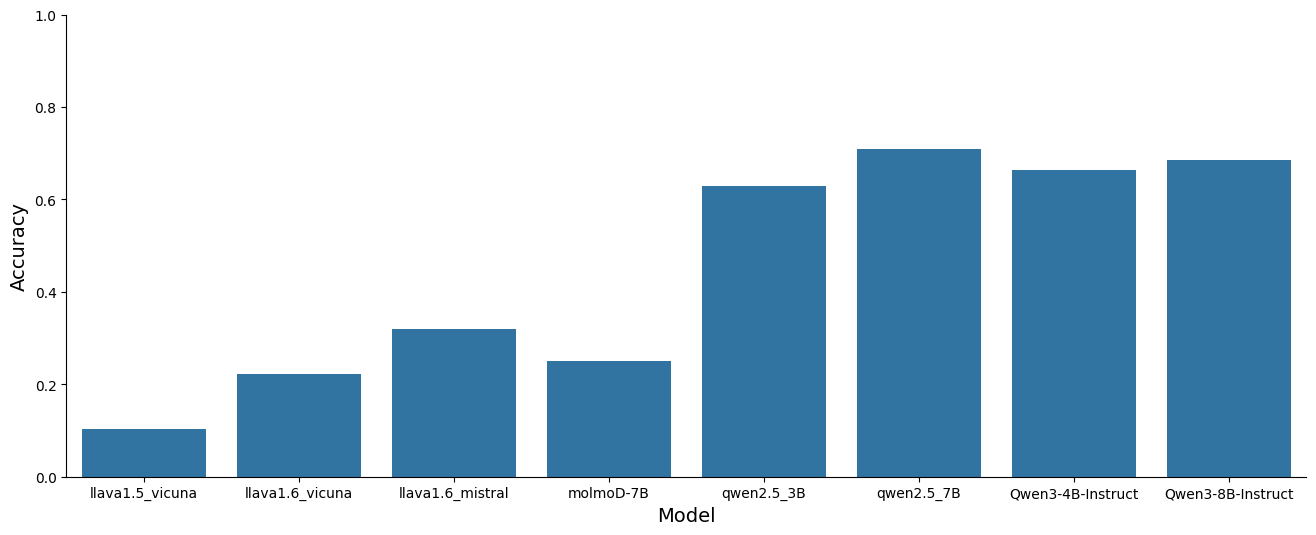

In [2]:
model_ls = [
    'llava-1.5-7b', 
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B', 
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]
# 'gemma3-4B', 'gemma3-12B',
path = f'{os.getcwd()}/../../results/'

acc_ls = []

for model in model_ls:
    files = os.listdir(f'{path}/{model}')
    file = [file for file in files if '.csv' in file and 'MATE' in file and model in file][0]
    prediction_df = pd.read_csv(f'{path}/{model}/{file}')
    
    if model=='llava-1.5-7b':
        acc_ls = acc_ls + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]
    else:
        acc_ls = acc_ls + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]

print(acc_ls)
fig,ax = plt.subplots(1,1,figsize=(16,6))

model_names = [
    'llava1.5_vicuna', 
    'llava1.6_vicuna', 
    'llava1.6_mistral', 
    'molmoD-7B', 
    'qwen2.5_3B', 
    'qwen2.5_7B',
    'Qwen3-4B-Instruct',
    'Qwen3-8B-Instruct',
]

b = sns.barplot(data=pd.DataFrame({'Model':model_names, 'Accuracy':acc_ls}), 
                                x='Model', y='Accuracy',ax=ax, color=sns.color_palette("tab10")[0])
b.set_xlabel(b.get_xlabel(), fontsize=14)
b.set_ylabel(b.get_ylabel(), fontsize=14)
b.set(ylim=(0, 1))
sns.despine(top=True, right=True)

[0.6420426375805652, 0.6494794248884482, 0.6207238472979673, 0.865146256817055, 0.66038671294001, 0.7020327218641547, 0.903321764997521, 0.6945959345562717]


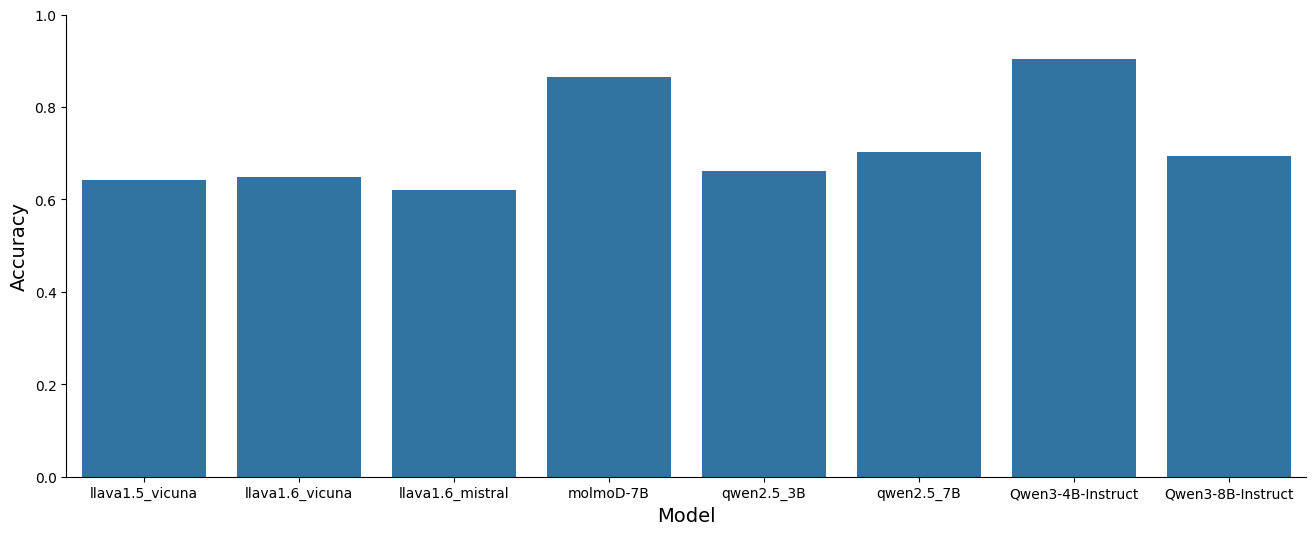

In [16]:
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

# 'gemma3-4B', 'gemma3-12B',
path = f'{os.getcwd()}/../../results/'

acc_ls = []
for model in model_ls:
    files = os.listdir(f'{path}/{model}')
    for file in files:
        if '.csv' in file and 'ScienceQA' in file:
            prediction_df = pd.read_csv(f'{path}/{model}/{file}')

    acc_ls = acc_ls + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]

print(acc_ls)
fig,ax = plt.subplots(1,1,figsize=(16,6))

# acc_ls = [0.1, 0.22, 0.32, 0.47, 0.58, 0.63, 0.71]
model_names = [
    'llava1.5_vicuna',
    'llava1.6_vicuna', 
    'llava1.6_mistral', 
    'molmoD-7B',
    'qwen2.5_3B', 
    'qwen2.5_7B',
    'Qwen3-4B-Instruct',
    'Qwen3-8B-Instruct',
]

b = sns.barplot(data=pd.DataFrame({'Model':model_names, 'Accuracy':acc_ls}), 
                                x='Model', y='Accuracy',ax=ax, color=sns.color_palette("tab10")[0])
b.set_xlabel(b.get_xlabel(), fontsize=14)
b.set_ylabel(b.get_ylabel(), fontsize=14)
b.set(ylim=(0, 1))
sns.despine(top=True, right=True)

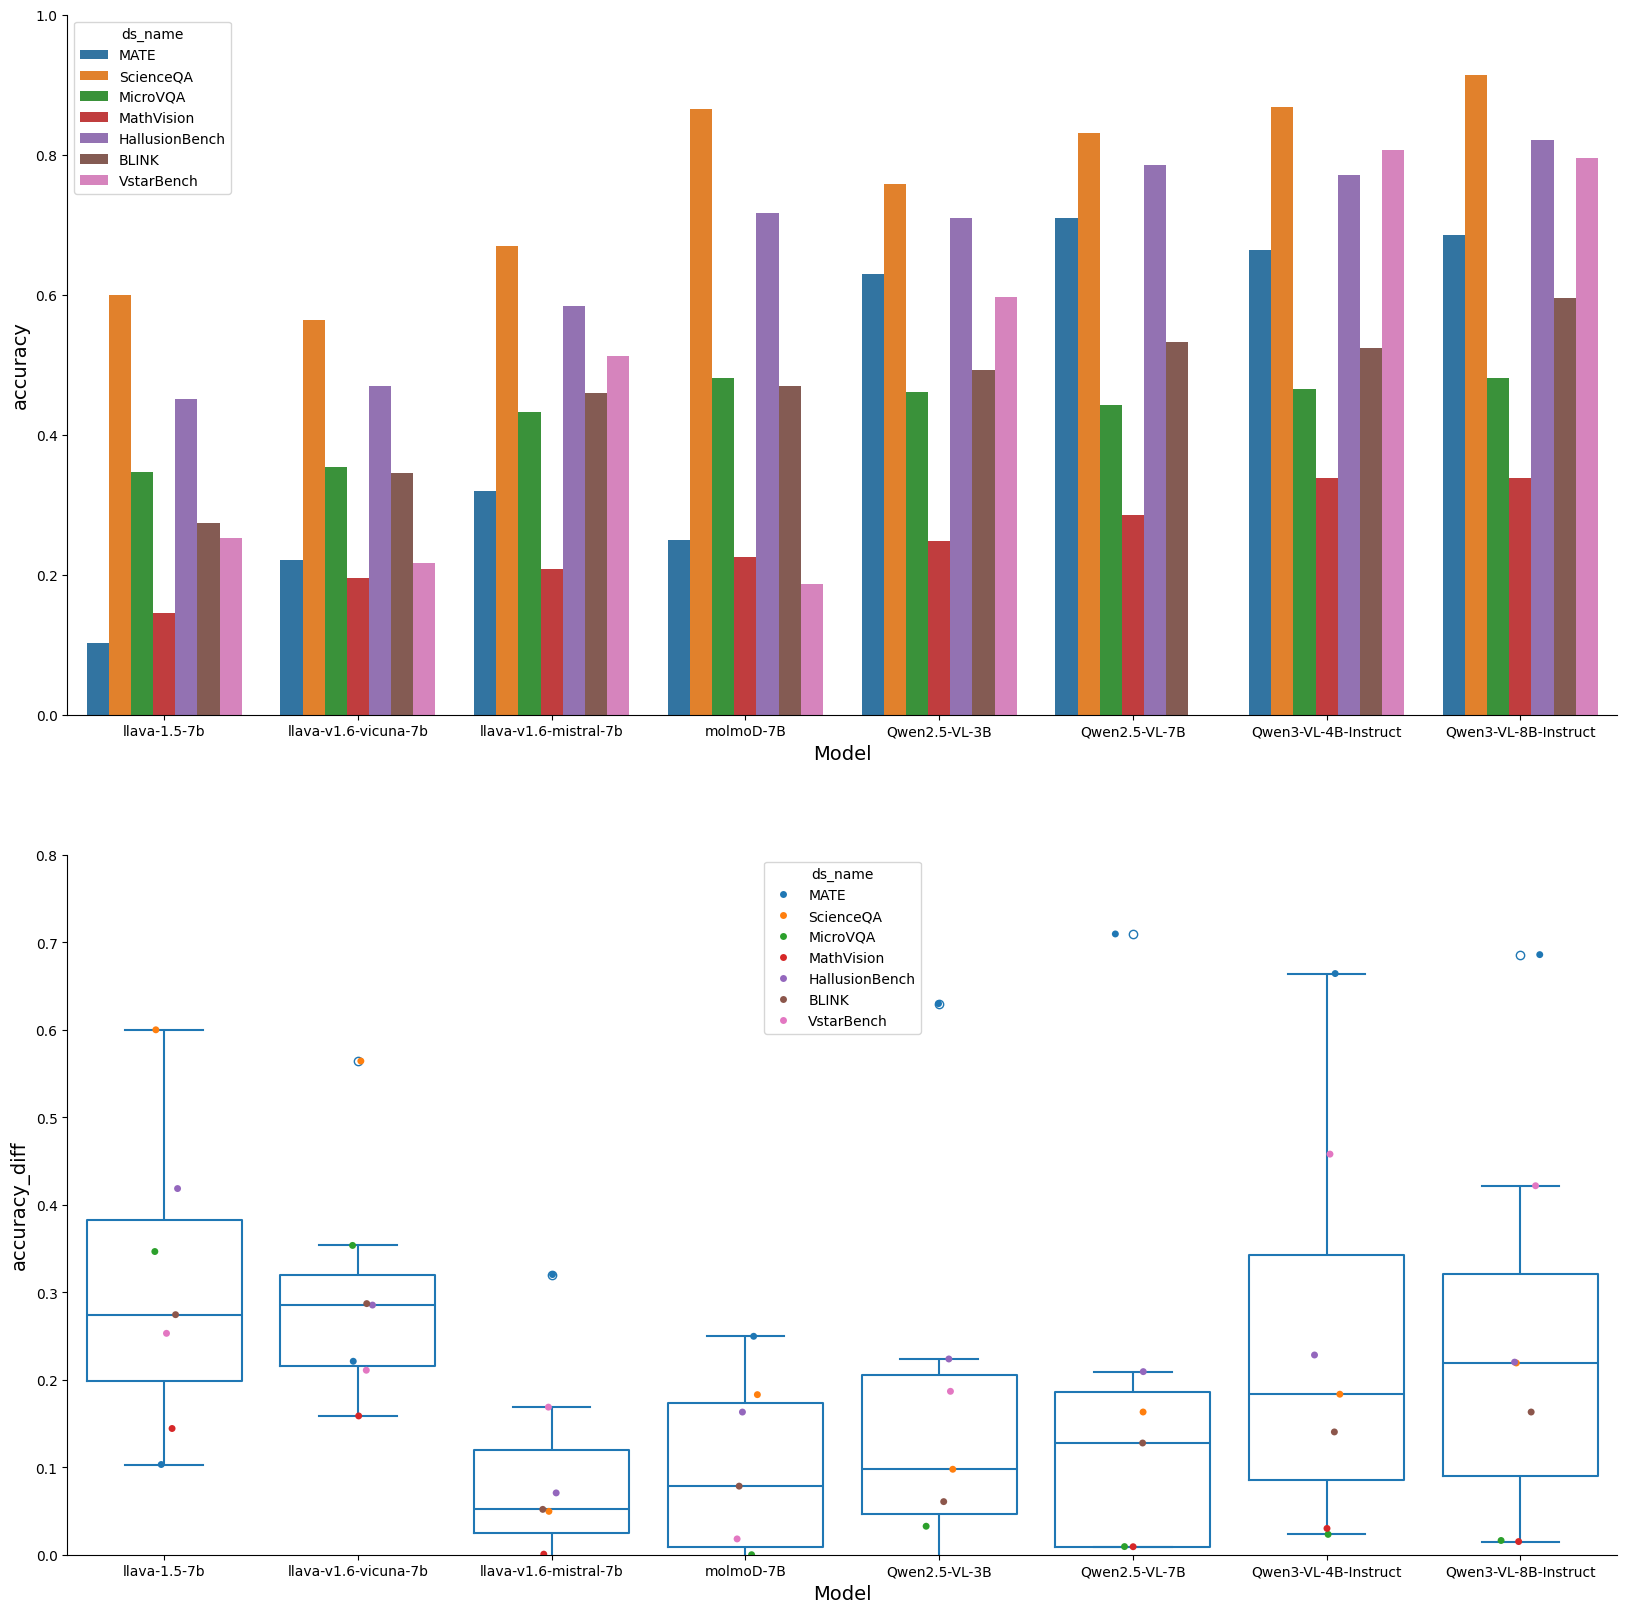

In [27]:
model_ls = [
    'llava-1.5-7b', 
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B', 
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

path = f'{os.getcwd()}/../../results/'

dfs = []
for ds_name in ds_names:
    results_dict = {
        'Model': model_ls,
        'accuracy': [],
        'accuracy_withoutImg': [],
    }

    for model in model_ls:
        # print(model)
        prediction_df = None
        #### Calculate Accuracy - withImg
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            if ds_name == 'MATE':
                if '.csv' in file and ds_name in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            elif ds_name == 'ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHint_' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            elif ds_name == 'VstarBench' and model == 'Qwen2.5-VL-7B':
                prediction_df = pd.DataFrame({'prediction':[0], 'gold_reference': [1]})   
            else:  
                if '.csv' in file and ds_name in file and 'without' not in file:
                    # print(file, ds_name, model)
                    prediction_df = pd.read_csv(f'{path}/{file}')
            
        if ds_name == 'MATE':
            if model=='llava-1.5-7b':
                results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]  
            else:
               results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]
        else:
            results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]
        
        #### Calculate Accuracy - withoutImg
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            if ds_name=='ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHintwithoutImg' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            else:
                if '.csv' in file and ds_name in file and 'withoutImg' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')

        if ds_name=='MATE':
            results_dict['accuracy_withoutImg'] = [0]*len(model_ls)
        else:
            results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]
    
    results_df = pd.DataFrame(results_dict)
    results_df['accuracy_diff'] = results_df['accuracy'] - results_df['accuracy_withoutImg']
    results_df['ds_name'] = [ds_name]*len(model_ls)
    
    dfs = dfs + [results_df]

dfs = pd.concat(dfs)    
fig,ax = plt.subplots(2,1,figsize=(20,20))
    
# model_names = [
#     'llava1.5_vicuna', 
#     'llava1.6_vicuna', 
#     'llava1.6_mistral', 
#     'molmoD-7B', 
#     'qwen2.5_3B', 
#     'qwen2.5_7B',
#     'Qwen3-4B-Instruct',
#     'Qwen3-8B-Instruct',
# ]

b = sns.barplot(
    data=dfs,
    x='Model', 
    y='accuracy',
    ax=ax[0],
    hue='ds_name'
)
b.set_xlabel(b.get_xlabel(), fontsize=14)
b.set_ylabel(b.get_ylabel(), fontsize=14)
b.set(ylim=(0, 1))


b = sns.boxplot(
    data=dfs,
    x='Model', 
    y='accuracy_diff',
    fill=False,
    ax=ax[1],

)

sns.stripplot(
    data=dfs,
    x='Model', 
    y='accuracy_diff',
    ax=b,
    hue='ds_name'
)
b.set_xlabel(b.get_xlabel(), fontsize=14)
b.set_ylabel(b.get_ylabel(), fontsize=14)
b.set(ylim=(0, 0.8))

sns.despine(top=True, right=True)

In [34]:
dfs

,Model,accuracy,accuracy_withoutImg,accuracy_diff,ds_name
0,llava-1.5-7b,0.103091,0.103091,0.000000,MATE
1,llava-v1.6-vicuna-7b,0.221091,0.221091,0.000000,MATE
2,llava-v1.6-mistral-7b,0.320182,0.320182,0.000000,MATE
3,molmoD-7B,0.249636,0.249636,0.000000,MATE
4,Qwen2.5-VL-3B,0.629818,0.629818,0.000000,MATE
5,Qwen2.5-VL-7B,0.709455,0.709455,0.000000,MATE
6,Qwen3-VL-4B-Instruct,0.664182,0.664182,0.000000,MATE
7,Qwen3-VL-8B-Instruct,0.685818,0.685818,0.000000,MATE
0,llava-1.5-7b,0.599901,0.000000,0.599901,ScienceQA
1,llava-v1.6-vicuna-7b,0.564204,0.000000,0.564204,ScienceQA


In [53]:
fig = go.Figure()

for model in model_ls:
    sub = dfs[dfs["Model"]==model]

    fig.add_trace(go.Scatterpolar(
        r=sub["accuracy"],
        theta=sub["ds_name"],
        fill="toself",
        name=model,
        opacity=0.5
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(range=[0, 1], tickfont=dict(size=10))
    ),
    legend=dict(orientation="h", y=-0.2),
)

fig.show()

In [15]:
fig = go.Figure()

for model in model_ls:
    sub = dfs[dfs["Model"] == model]

    fig.add_trace(go.Scatterpolar(
        r=sub["accuracy"],
        theta=sub["ds_name"],
        fill="toself",
        name=model,
        opacity=0.5
    ))

fig.update_layout(
    width=900,          # ← increase width
    height=900,         # ← increase height
    polar=dict(
        radialaxis=dict(
            range=[0, 1],
            tickfont=dict(size=14)   # bigger radial ticks
        ),
        angularaxis=dict(
            tickfont=dict(size=20)   # bigger category labels
        )
    ),
    legend=dict(
        orientation="h",
        y=-0.1,
        x=0.5,
        font=dict(size=14)
    ),
    margin=dict(l=80, r=80, t=80, b=120)
)

fig.show()
